# 2. Prophet Model

In this notebook, we load our preprocessed time-series data and train **cluster-specific** Prophet models. Facebook Prophet is highly effective at capturing multiple seasonalities (daily and weekly), making it ideal for forecasting the distinct behavioral patterns of our clusters.

## 1. Imports and Data Loading
We import `pandas` for data handling, `prophet` for our core forecasting algorithm, and `scikit-learn` strictly for evaluating our business metric (MAPE). We then load our highly compressed Parquet data alongside our predefined client clusters.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import logging
import seaborn as sns

from tqdm import tqdm
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# Suppress verbose Prophet/stan console warnings to keep the notebook clean
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# Load Data
print("Loading processed data...")
df_long = pd.read_parquet('../Datasets/processed_electricity_data.parquet')

print("Merging cluster definitions...")
cluster_map = pd.read_csv('../Datasets/client_clusters.csv')
df_long = df_long.merge(cluster_map, on='ClientID', how='left')

Loading processed data...
Merging cluster definitions...


### 2. Cluster-Based Prophet Modeling
Unlike standard regression, Facebook Prophet decomposes time series into trend, seasonality, and holidays. To satisfy the requirement of building **one model per cluster**, we aggregate the historical training data by calculating the average consumption for each cluster at each timestamp. 
We then train 5 distinct Prophet models. This captures the unique daily and weekly seasonalities of each consumer group (e.g., standard business vs. night-shift) while keeping computational latency extremely low.

In [ ]:
# Per-Client Standardization & Cluster Aggregation
print("Standardizing each client to extract behavioral shapes...")
df_long = df_long.sort_values(by=['ClientID', 'Date'])
client_scalers = {}
df_long['Consumption_Scaled'] = np.nan

# Scale each client individually to remove absolute volume bias
for client in tqdm(df_long['ClientID'].unique(), desc="Scaling Clients"):
    mask = df_long['ClientID'] == client
    scaler = StandardScaler()
    df_long.loc[mask, 'Consumption_Scaled'] = scaler.fit_transform(
        df_long.loc[mask, 'Consumption'].values.reshape(-1, 1)
    ).flatten()
    client_scalers[client] = scaler

print("\nAggregating historical SCALED data by Cluster...")
# We aggregate the SCALED consumption to learn the pure pattern
cluster_df = df_long.groupby(['Cluster', 'Date'], observed=True).agg({
    'Consumption_Scaled': 'mean',
    'HDH': 'first', 
    'CDH': 'first'
}).reset_index()

# Prophet requires 'ds' and 'y'
cluster_df = cluster_df.rename(columns={'Date': 'ds', 'Consumption_Scaled': 'y'})

train_df = cluster_df[cluster_df['ds'].dt.year < 2014].copy()
test_df  = cluster_df[cluster_df['ds'].dt.year >= 2014].copy()

Standardizing each client to extract behavioral shapes...


Scaling Clients: 100%|██████████| 370/370 [00:37<00:00,  9.81it/s]



Aggregating historical SCALED data by Cluster...


In [ ]:
# Train Cluster Models & Forecast Individual Clients
cluster_models = {}
cluster_forecasts = {} # Stores the scaled pattern forecast for each cluster

unique_clusters = train_df['Cluster'].dropna().unique()

for cluster_id in tqdm(sorted(unique_clusters), desc="Training Prophet per Cluster"):
    df_train_c = train_df[train_df['Cluster'] == cluster_id]
    df_test_c  = test_df[test_df['Cluster'] == cluster_id]

    # Initialize and fit
    m = Prophet(changepoint_prior_scale=0.15, uncertainty_samples=0, daily_seasonality=False)
    m.add_seasonality(name='daily', period=1, fourier_order=24) 
    m.add_country_holidays(country_name='PT')
    m.add_regressor('HDH') 
    m.add_regressor('CDH')
    m.fit(df_train_c)
    
    cluster_models[cluster_id] = m

    # Forecast the scaled pattern for the cluster
    future = df_test_c[['ds', 'HDH', 'CDH']].copy()
    forecast = m.predict(future)
    cluster_forecasts[cluster_id] = forecast['yhat'].values


print("\nTranslating cluster patterns to individual client kW forecasts...")
client_results = []

# Now we test how well this works for INDIVIDUAL clients (like Client 12)
df_test_raw = df_long[df_long['Date'].dt.year >= 2014].copy()

for client in tqdm(df_test_raw['ClientID'].unique(), desc="Evaluating Clients"):
    client_data = df_test_raw[df_test_raw['ClientID'] == client]
    if len(client_data) == 0 or client not in client_scalers: continue
        
    cluster_id = client_data['Cluster'].values[0]
    
    # --- FIX: Check if cluster_id is NaN to prevent KeyError ---
    if pd.isna(cluster_id):
        continue
    
    # 1. Get the generic scaled shape from the client's cluster model
    pattern_forecast = cluster_forecasts[cluster_id][:len(client_data)]
    
    # 2. Use the client's specific scaler to multiply the shape into raw kW
    scaler = client_scalers[client]
    y_pred_kw = scaler.inverse_transform(pattern_forecast.reshape(-1, 1)).flatten()
    y_pred_kw = np.maximum(y_pred_kw, 0) # No negative electricity
    
    # 3. Calculate MAPE against actual kW
    y_true_kw = client_data['Consumption'].values
    nonzero_mask = y_true_kw > 0.1
    
    if nonzero_mask.sum() > 0:
        mape = np.mean(np.abs((y_true_kw[nonzero_mask] - y_pred_kw[nonzero_mask]) / y_true_kw[nonzero_mask])) * 100
    else:
        mape = 0.0
        
    # Store results for the benchmark table
    client_results.append({'ClientID': client, 'MAPE': mape})


# ---------------------------------------------------------
# Prophet Benchmark & Performance Breakdown
# ---------------------------------------------------------
pr_results_df = pd.DataFrame(client_results)

print("\n--- PROPHET BENCHMARK RESULTS ---")
print(f"Global Average MAPE: {pr_results_df['MAPE'].mean():.2f}%")

# Merge with cluster map to group results by Cluster
pr_results_df = pr_results_df.merge(cluster_map, on='ClientID', how='inner')

print("\n--- PROPHET PERFORMANCE BY CLUSTER ---\n")
summary = pr_results_df.groupby('Cluster').agg(
    n_clients=('ClientID', 'count'),
    Average_MAPE=('MAPE', 'mean')
).round(2)

print(summary.to_string())

Training Prophet per Cluster: 100%|██████████| 5/5 [03:18<00:00, 39.68s/it]



Translating cluster patterns to individual client kW forecasts...


Evaluating Clients: 100%|██████████| 370/370 [00:10<00:00, 35.14it/s]


--- PROPHET BENCHMARK RESULTS ---
Global Average MAPE: 56.14%

--- PROPHET PERFORMANCE BY CLUSTER ---

         n_clients  Average_MAPE
Cluster                         
0               28         80.86
1               69         55.10
2               70        131.28
3              173         20.96
4               11         74.84


## 4. Forecasting Visualization
To visually validate our Prophet models, we plot the actual vs. predicted consumption for one representative client per cluster. 
We reconstruct the specific client's forecast by taking the pure behavioral pattern learned by the cluster's Prophet model and un-scaling it using the client's individual `StandardScaler`. We slice the plot to show only the **last 14 days** to ensure the daily seasonal curves are readable.

Generating validation plots...


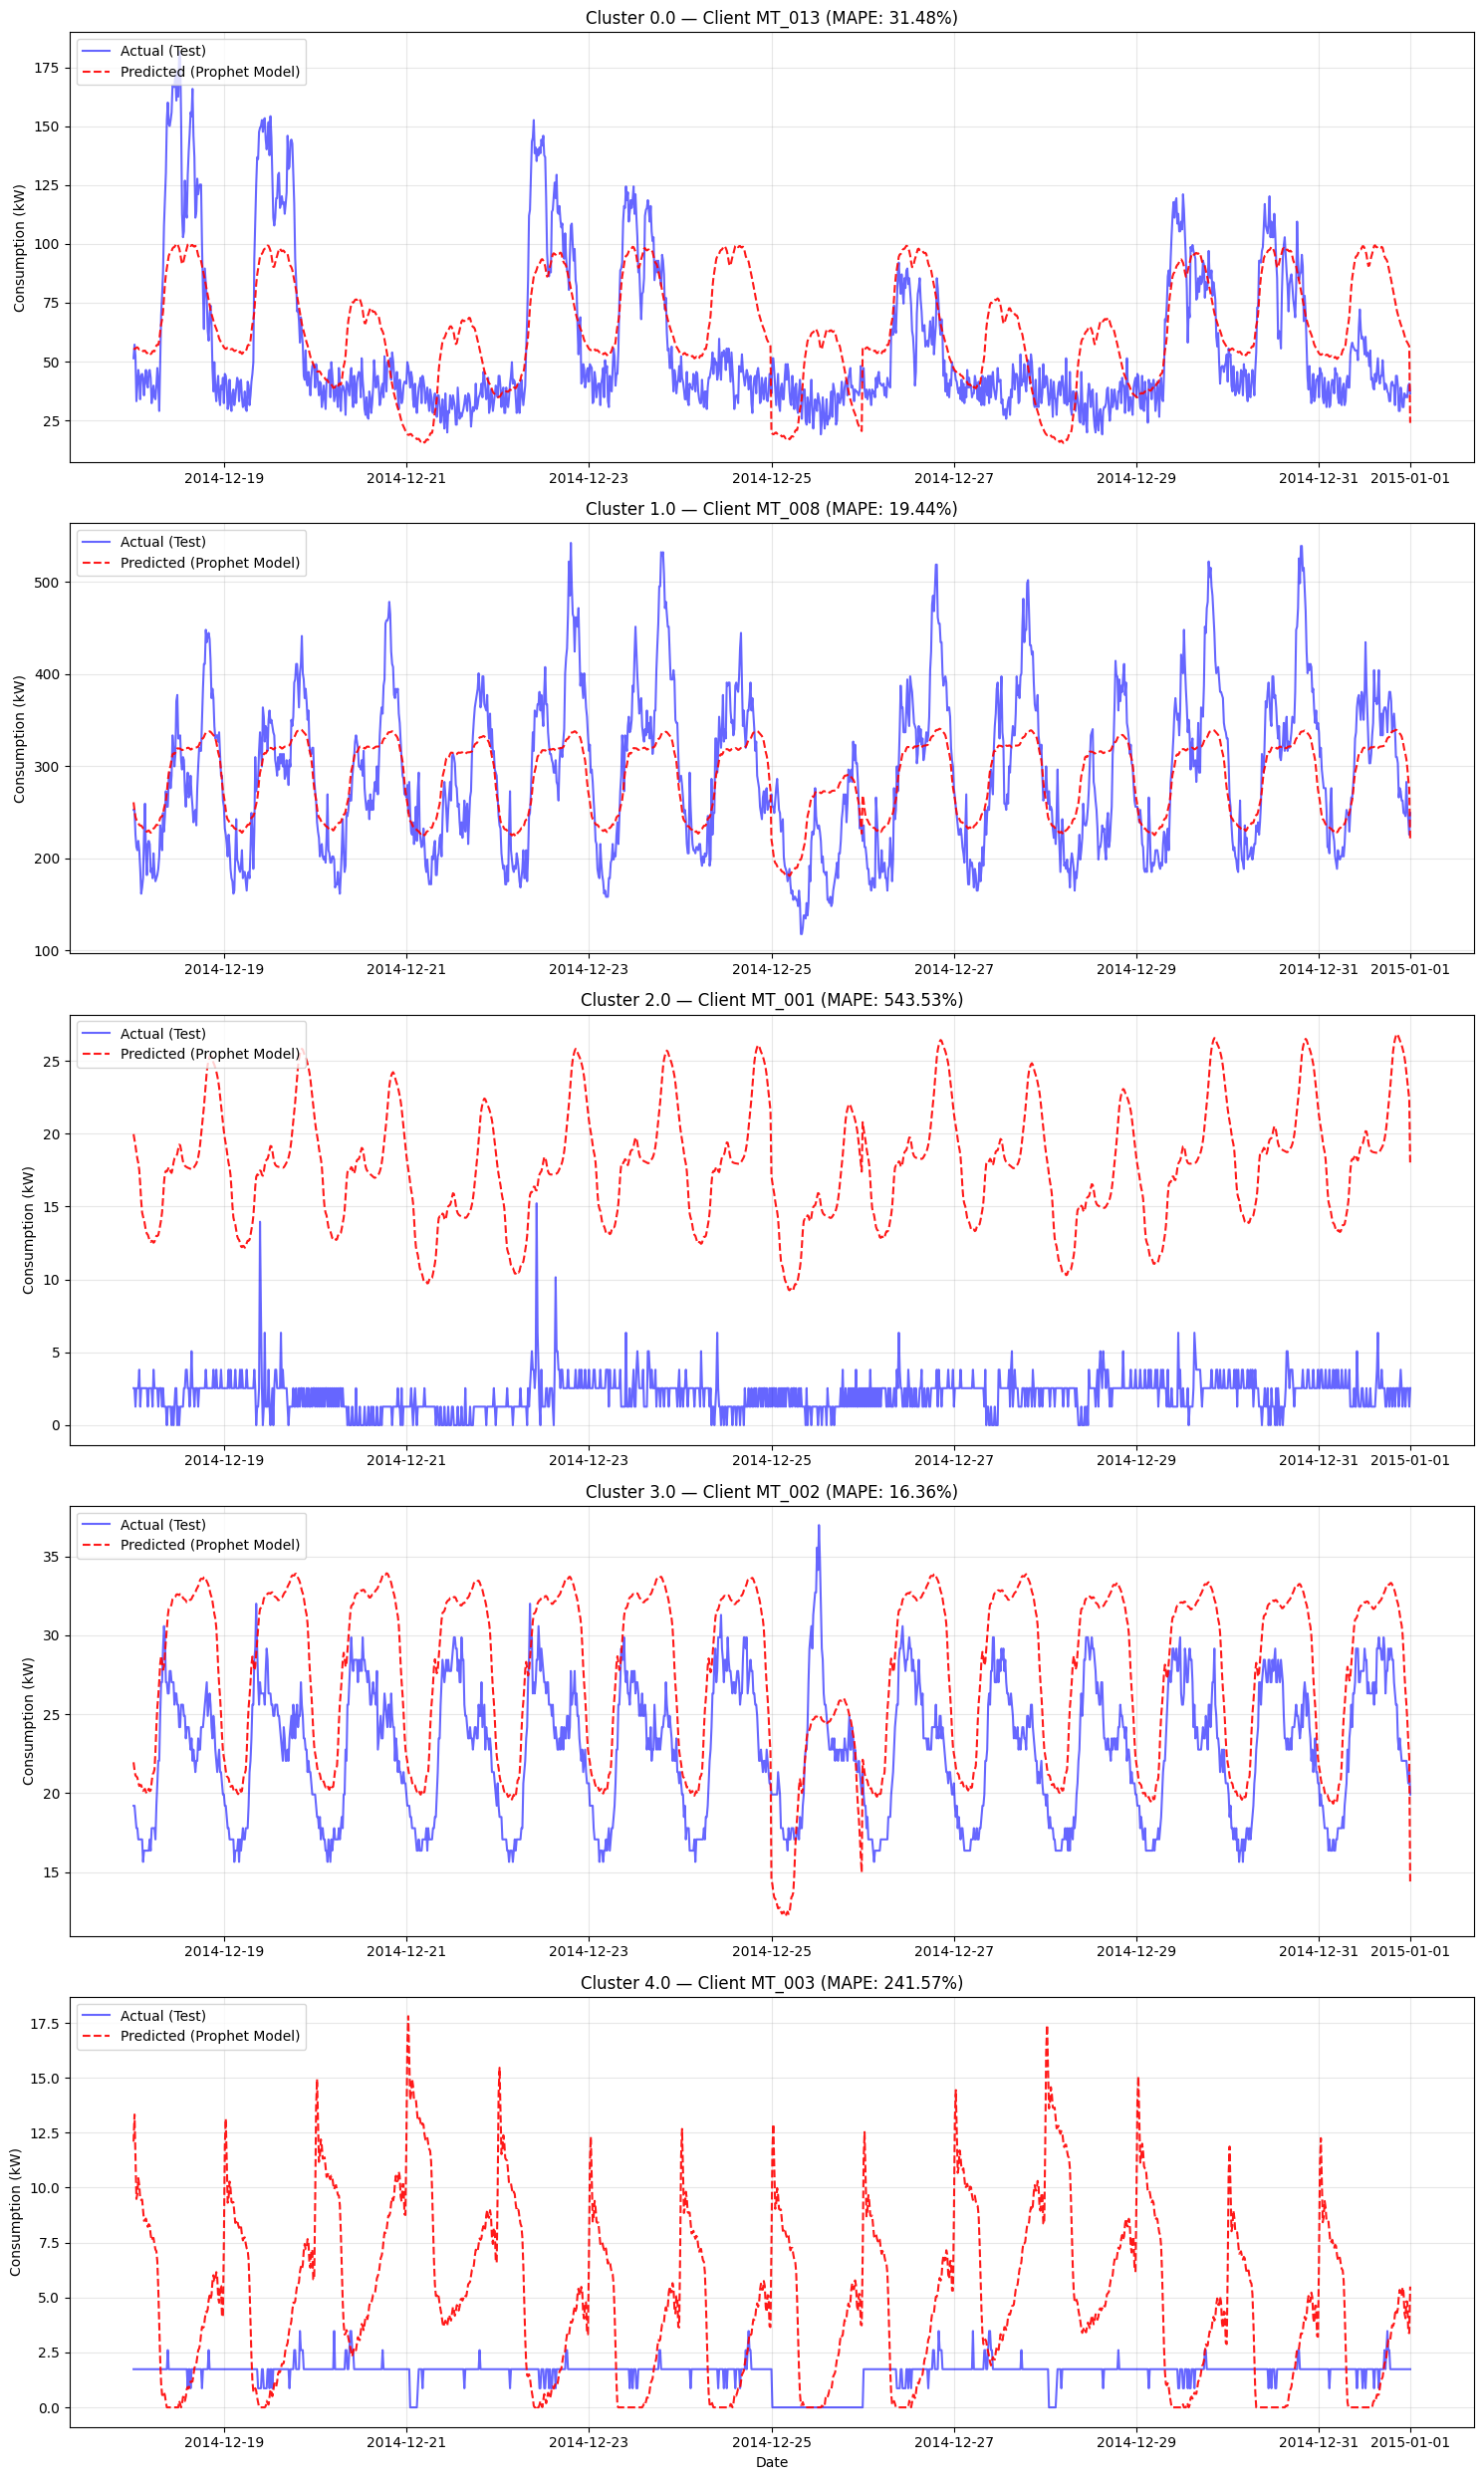

In [19]:
# Visualization: One Client per Cluster
print("Generating validation plots...")

# 1. Select one representative client for each cluster dynamically
cluster_representatives = df_test_raw.groupby('Cluster')['ClientID'].first().to_dict()

# 2. Setup the Matplotlib figure
fig, axes = plt.subplots(len(cluster_representatives), 1, figsize=(15, 5 * len(cluster_representatives)))

for idx, (cluster_id, client_id) in enumerate(sorted(cluster_representatives.items())):
    ax = axes[idx] if len(cluster_representatives) > 1 else axes

    # Extract actual historical test data for this specific client
    client_data = df_test_raw[df_test_raw['ClientID'] == client_id].copy()
    y_actual_kw = client_data['Consumption'].values
    dates = client_data['Date'].values

    # Reconstruct the forecast: Get cluster shape and un-scale to Client's raw kW
    pattern_forecast = cluster_forecasts[cluster_id][:len(client_data)]
    scaler = client_scalers[client_id]
    y_pred_kw = scaler.inverse_transform(pattern_forecast.reshape(-1, 1)).flatten()
    y_pred_kw = np.maximum(y_pred_kw, 0) # Floor to zero

    # Calculate individual MAPE to display on the chart
    nonzero_mask = y_actual_kw > 0.1
    if nonzero_mask.sum() > 0:
        client_mape = np.mean(np.abs((y_actual_kw[nonzero_mask] - y_pred_kw[nonzero_mask]) / y_actual_kw[nonzero_mask])) * 100
    else:
        client_mape = 0.0

    # VISUAL OPTIMIZATION: slice the array to plot only the last 2 weeks (14 days * 96 steps = 1344 steps)
    plot_slice = -1344 

    ax.plot(dates[plot_slice:], y_actual_kw[plot_slice:],
            label='Actual (Test)', color='blue', alpha=0.6)
    ax.plot(dates[plot_slice:], y_pred_kw[plot_slice:],
            label='Predicted (Prophet Model)', color='red', linestyle='--', alpha=0.9)

    ax.set_title(f'Cluster {cluster_id} — Client {client_id} (MAPE: {client_mape:.2f}%)')
    ax.set_ylabel('Consumption (kW)')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

## 5. Testing Results: Time Period Analysis & Error Box Plots
To evaluate the temporal stability of our Prophet models, we must assess how the forecasting error evolves over time. 

We dynamically reconstruct the unscaled individual predictions for all clients and append them to an evaluation dataframe. We then strictly divide the testing year into 4 equal chronological periods (Q1 to Q4). Finally, we report the global MAPE per period and visualize the spread of the Absolute Percentage Error (APE) using box plots, hiding extreme outliers (caused by near-zero actuals) to maintain visual clarity.

Preparing data for Time Period Analysis...


Generating predictions for Box Plots: 100%|██████████| 370/370 [00:12<00:00, 29.17it/s]



--- MAPE BY TIME PERIOD (PROPHET) ---
Period 1: 52.03%
Period 2: 55.72%
Period 3: 55.03%
Period 4: 49.86%


/var/folders/lx/q9_kw781689fhd96mw2q267r0000gn/T/ipykernel_10068/2967156592.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eval_valid, x='Time_Period', y='APE', palette='Set2', showfliers=False)


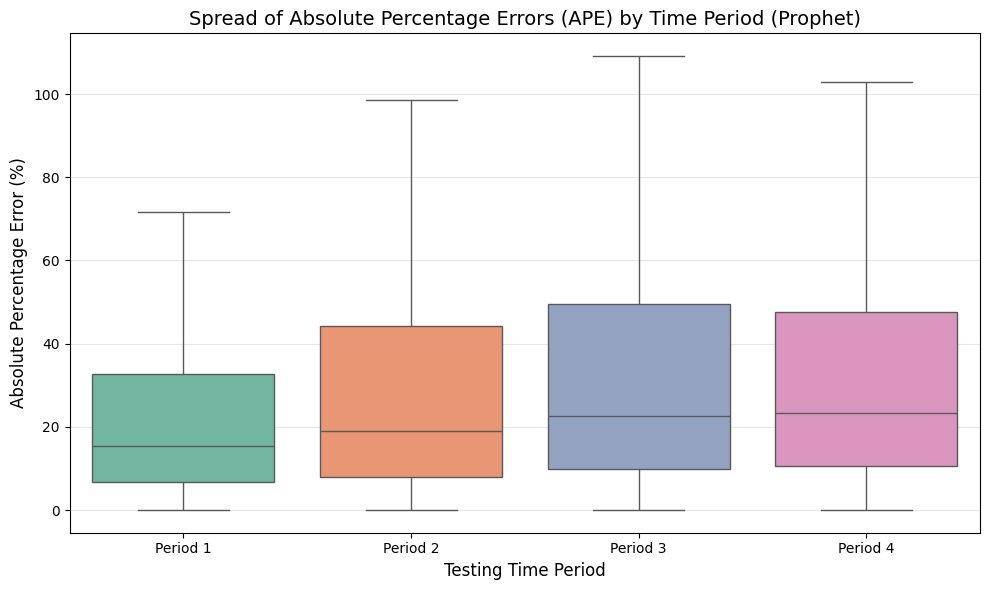

In [20]:
# Time Period Analysis & Error Spread
print("Preparing data for Time Period Analysis...")

# Create a clean evaluation dataframe from our raw test data
df_eval = df_test_raw.copy()
df_eval['Predicted_kW'] = np.nan

# Quickly reconstruct the predictions for all valid clients
for client in tqdm(df_eval['ClientID'].unique(), desc="Generating predictions for Box Plots"):
    mask = df_eval['ClientID'] == client
    
    # Skip if client has no data or no scaler
    if mask.sum() == 0 or client not in client_scalers:
        continue
        
    cluster_id = df_eval.loc[mask, 'Cluster'].values[0]
    if pd.isna(cluster_id):
        continue

    # Get generic scaled shape and unscale to raw kW
    pattern_forecast = cluster_forecasts[cluster_id][:mask.sum()]
    scaler = client_scalers[client]
    unscaled = scaler.inverse_transform(pattern_forecast.reshape(-1, 1)).flatten()
    
    # Floor to zero and save to the evaluation dataframe
    df_eval.loc[mask, 'Predicted_kW'] = np.maximum(unscaled, 0)

# Drop rows where we couldn't make a prediction
df_eval = df_eval.dropna(subset=['Consumption', 'Predicted_kW'])

# Sort chronologically to ensure periods are perfectly sequential
df_eval = df_eval.sort_values('Date')

# Divide strictly into 4 equal time periods using pd.cut
df_eval['Time_Period'] = pd.cut(df_eval['Date'], bins=4, labels=['Period 1', 'Period 2', 'Period 3', 'Period 4'])

# Calculate Absolute Percentage Error (APE) row by row
# We filter out actual values close to zero to prevent infinity (division by zero)
valid_mask = df_eval['Consumption'] > 0.1
df_eval_valid = df_eval[valid_mask].copy()

df_eval_valid['APE'] = np.abs((df_eval_valid['Consumption'] - df_eval_valid['Predicted_kW']) / df_eval_valid['Consumption']) * 100

# 1. Print the global MAPE for each period
print("\n--- MAPE BY TIME PERIOD (PROPHET) ---")
period_mape = df_eval_valid.groupby('Time_Period', observed=True)['APE'].mean()
for period, mape_val in period_mape.items():
    print(f"{period}: {mape_val:.2f}%")

# 2. Plot the Box Plot of errors
plt.figure(figsize=(10, 6))

# We use showfliers=False because raw percentage errors can have massive outlier spikes
sns.boxplot(data=df_eval_valid, x='Time_Period', y='APE', palette='Set2', showfliers=False)

plt.title('Spread of Absolute Percentage Errors (APE) by Time Period (Prophet)', fontsize=14)
plt.ylabel('Absolute Percentage Error (%)', fontsize=12)
plt.xlabel('Testing Time Period', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# 2. Initialize Metric Trackers
# ---------------------------------------------------------
all_wmapes = []
all_mapes  = []
all_maes   = []
all_mses   = []
all_rmses  = []

# ---------------------------------------------------------
# 3. The Grand Prophet Loop
# ---------------------------------------------------------
FORECAST_HORIZON = 96
all_predictions  = {}

for client_id in tqdm(sampled_clients, desc="Training Prophet Models"):
    client_df = df_long[df_long['ClientID'] == client_id].copy()
    client_df = client_df.rename(columns={'Date': 'ds', 'Consumption': 'y'})
    client_df = client_df.sort_values('ds').reset_index(drop=True)

    train_df = client_df.iloc[:-FORECAST_HORIZON]
    test_df  = client_df.iloc[-FORECAST_HORIZON:]

    m = Prophet(changepoint_prior_scale=0.15, daily_seasonality=False)
    m.add_country_holidays(country_name='PT')
    m.add_regressor('Temp_National_Avg')
    m.add_regressor('Lag_15min')
    m.add_regressor('Lag_24h')
    m.add_regressor('Rolling_Mean_4h')
    m.fit(train_df)

    future_steps = test_df[['ds', 'Temp_National_Avg']].copy().reset_index(drop=True)
    history_y    = list(train_df['y'].values)
    clean_predictions = []

    for step in range(FORECAST_HORIZON):
        current_step = future_steps.iloc[[step]].copy()
        current_step['Lag_15min']       = history_y[-1]
        current_step['Lag_24h']         = history_y[-96]
        current_step['Rolling_Mean_4h'] = np.mean(history_y[-16:])

        yhat = m.predict(current_step)['yhat'].values[0]
        clean_predictions.append(yhat)
        history_y.append(yhat)

    y_true = test_df['y'].values
    y_pred = np.maximum(np.array(clean_predictions), 0)

    sum_actual = np.sum(y_true)
    wmape = np.sum(np.abs(y_true - y_pred)) / sum_actual if sum_actual > 0 else 0.0
    all_wmapes.append(wmape)

    nz   = y_true > 0.1
    mape = np.mean(np.abs((y_true[nz] - y_pred[nz]) / y_true[nz])) if nz.sum() > 0 else 0.0
    all_mapes.append(mape)

    all_maes.append(mean_absolute_error(y_true, y_pred))
    all_mses.append(mean_squared_error(y_true, y_pred))
    all_rmses.append(np.sqrt(mean_squared_error(y_true, y_pred)))

    all_predictions[client_id] = {'test_df': test_df, 'y_pred': y_pred}

Training Prophet Models:   0%|          | 0/30 [00:00<?, ?it/s]

22:34:15 - cmdstanpy - INFO - Chain [1] start processing
22:34:42 - cmdstanpy - INFO - Chain [1] done processing
22:34:50 - cmdstanpy - INFO - Chain [1] start processing
22:34:54 - cmdstanpy - INFO - Chain [1] done processing
22:35:01 - cmdstanpy - INFO - Chain [1] start processing
22:35:05 - cmdstanpy - INFO - Chain [1] done processing
22:35:12 - cmdstanpy - INFO - Chain [1] start processing
22:35:18 - cmdstanpy - INFO - Chain [1] done processing
22:35:25 - cmdstanpy - INFO - Chain [1] start processing
22:35:35 - cmdstanpy - INFO - Chain [1] done processing
22:35:39 - cmdstanpy - INFO - Chain [1] start processing
22:35:40 - cmdstanpy - INFO - Chain [1] done processing
22:35:47 - cmdstanpy - INFO - Chain [1] start processing
22:35:55 - cmdstanpy - INFO - Chain [1] done processing
22:36:02 - cmdstanpy - INFO - Chain [1] start processing
22:36:08 - cmdstanpy - INFO - Chain [1] done processing
22:36:15 - cmdstanpy - INFO - Chain [1] start processing
22:36:18 - cmdstanpy - INFO - Chain [1]

In [ ]:
print("--- 30-CLIENT PROPHET BENCHMARK RESULTS ---")
print(f"Average MAPE:  {np.mean(all_mapes):.2%}")
print(f"Average WMAPE: {np.mean(all_wmapes):.2%}")
print(f"Average MAE:   {np.mean(all_maes):.2f} kW")
print(f"Average MSE:   {np.mean(all_mses):.2f}")
print(f"Average RMSE:  {np.mean(all_rmses):.2f} kW")

--- 30-CLIENT PROPHET BENCHMARK RESULTS ---
Average MAPE:  649.00%
Average WMAPE: 40.34%
Average MAE:   35.68 kW
Average MSE:   7205.04
Average RMSE:  50.45 kW


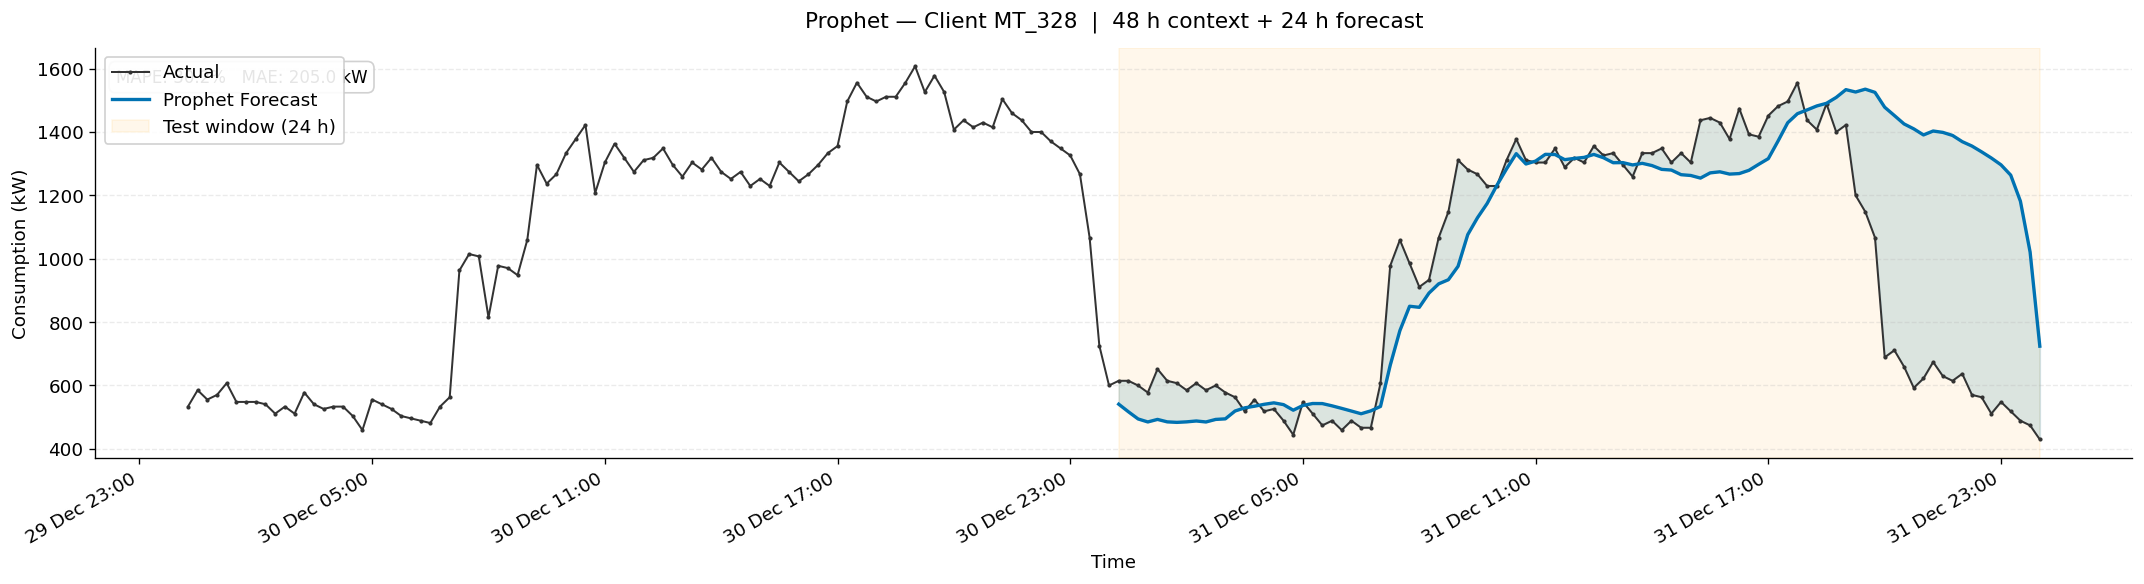

In [ ]:
# ---------------------------------------------------------
# 4. Visualization — First client forecast (48 h context + 24 h forecast)
# ---------------------------------------------------------
first_client = sampled_clients[0]
data = all_predictions[first_client]

zoom_idx = -192  # 48 h of context at 15-min resolution

client_df = df_long[df_long['ClientID'] == first_client].copy()
client_df = client_df.rename(columns={'Date': 'ds', 'Consumption': 'y'})
client_df = client_df.sort_values('ds').reset_index(drop=True)

first_idx = sampled_clients.index(first_client)
mae_val   = all_maes[first_idx]
mape_val  = all_mapes[first_idx]

fig, ax = plt.subplots(figsize=(18, 5))

ax.plot(client_df['ds'].iloc[zoom_idx:], client_df['y'].iloc[zoom_idx:],
        label='Actual', color='#333333', linewidth=1.2, marker='.', markersize=3)
ax.plot(data['test_df']['ds'], data['y_pred'],
        label='Prophet Forecast', color='#0072B2', linewidth=2)
ax.fill_between(data['test_df']['ds'],
                data['test_df']['y'].values, data['y_pred'],
                alpha=0.15, color='#0072B2')
ax.axvspan(data['test_df']['ds'].iloc[0], data['test_df']['ds'].iloc[-1],
           color='#FFA500', alpha=0.08, label='Test window (24 h)')

ax.text(0.01, 0.95, f"MAPE: {mape_val:.1%}   MAE: {mae_val:.1f} kW",
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='#cccccc', alpha=0.9))

ax.set_title(f"Prophet — Client {first_client}  |  48 h context + 24 h forecast", pad=12)
ax.set_xlabel('Time')
ax.set_ylabel('Consumption (kW)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, alpha=0.25, linestyle='--')
ax.xaxis.grid(False)
ax.legend(loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# 5. Performance Breakdown by Cluster
# ---------------------------------------------------------
cluster_map = pd.read_csv('../Datasets/client_clusters.csv')

results_df = pd.DataFrame({
    'ClientID': sampled_clients,
    'MAE':   all_maes,
    'RMSE':  all_rmses,
    'MAPE':  all_mapes,
    'WMAPE': all_wmapes
})

results_df = results_df.merge(cluster_map, on='ClientID')

print("--- PROPHET PERFORMANCE BY CLUSTER ---\n")
summary = results_df.groupby('Cluster').agg(
    n_clients=('ClientID', 'count'),
    MAE=('MAE', 'mean'),
    RMSE=('RMSE', 'mean'),
    MAPE=('MAPE', 'mean'),
    WMAPE=('WMAPE', 'mean')
).round(3)
# Format MAPE and WMAPE as percentages for readability
summary['MAPE']  = summary['MAPE'].map('{:.1%}'.format)
summary['WMAPE'] = summary['WMAPE'].map('{:.1%}'.format)
print(summary.to_string())

--- PROPHET PERFORMANCE BY CLUSTER ---

         n_clients     MAE    RMSE     MAPE  WMAPE
Cluster                                           
0                2  61.576  84.845    12.5%   7.9%
1                7  55.885  90.083    32.0%  23.6%
2                6  24.042  31.481    16.7%  16.7%
3                6  10.318  12.237    24.3%  23.8%
4                9  38.880  50.094  2108.3%  87.4%


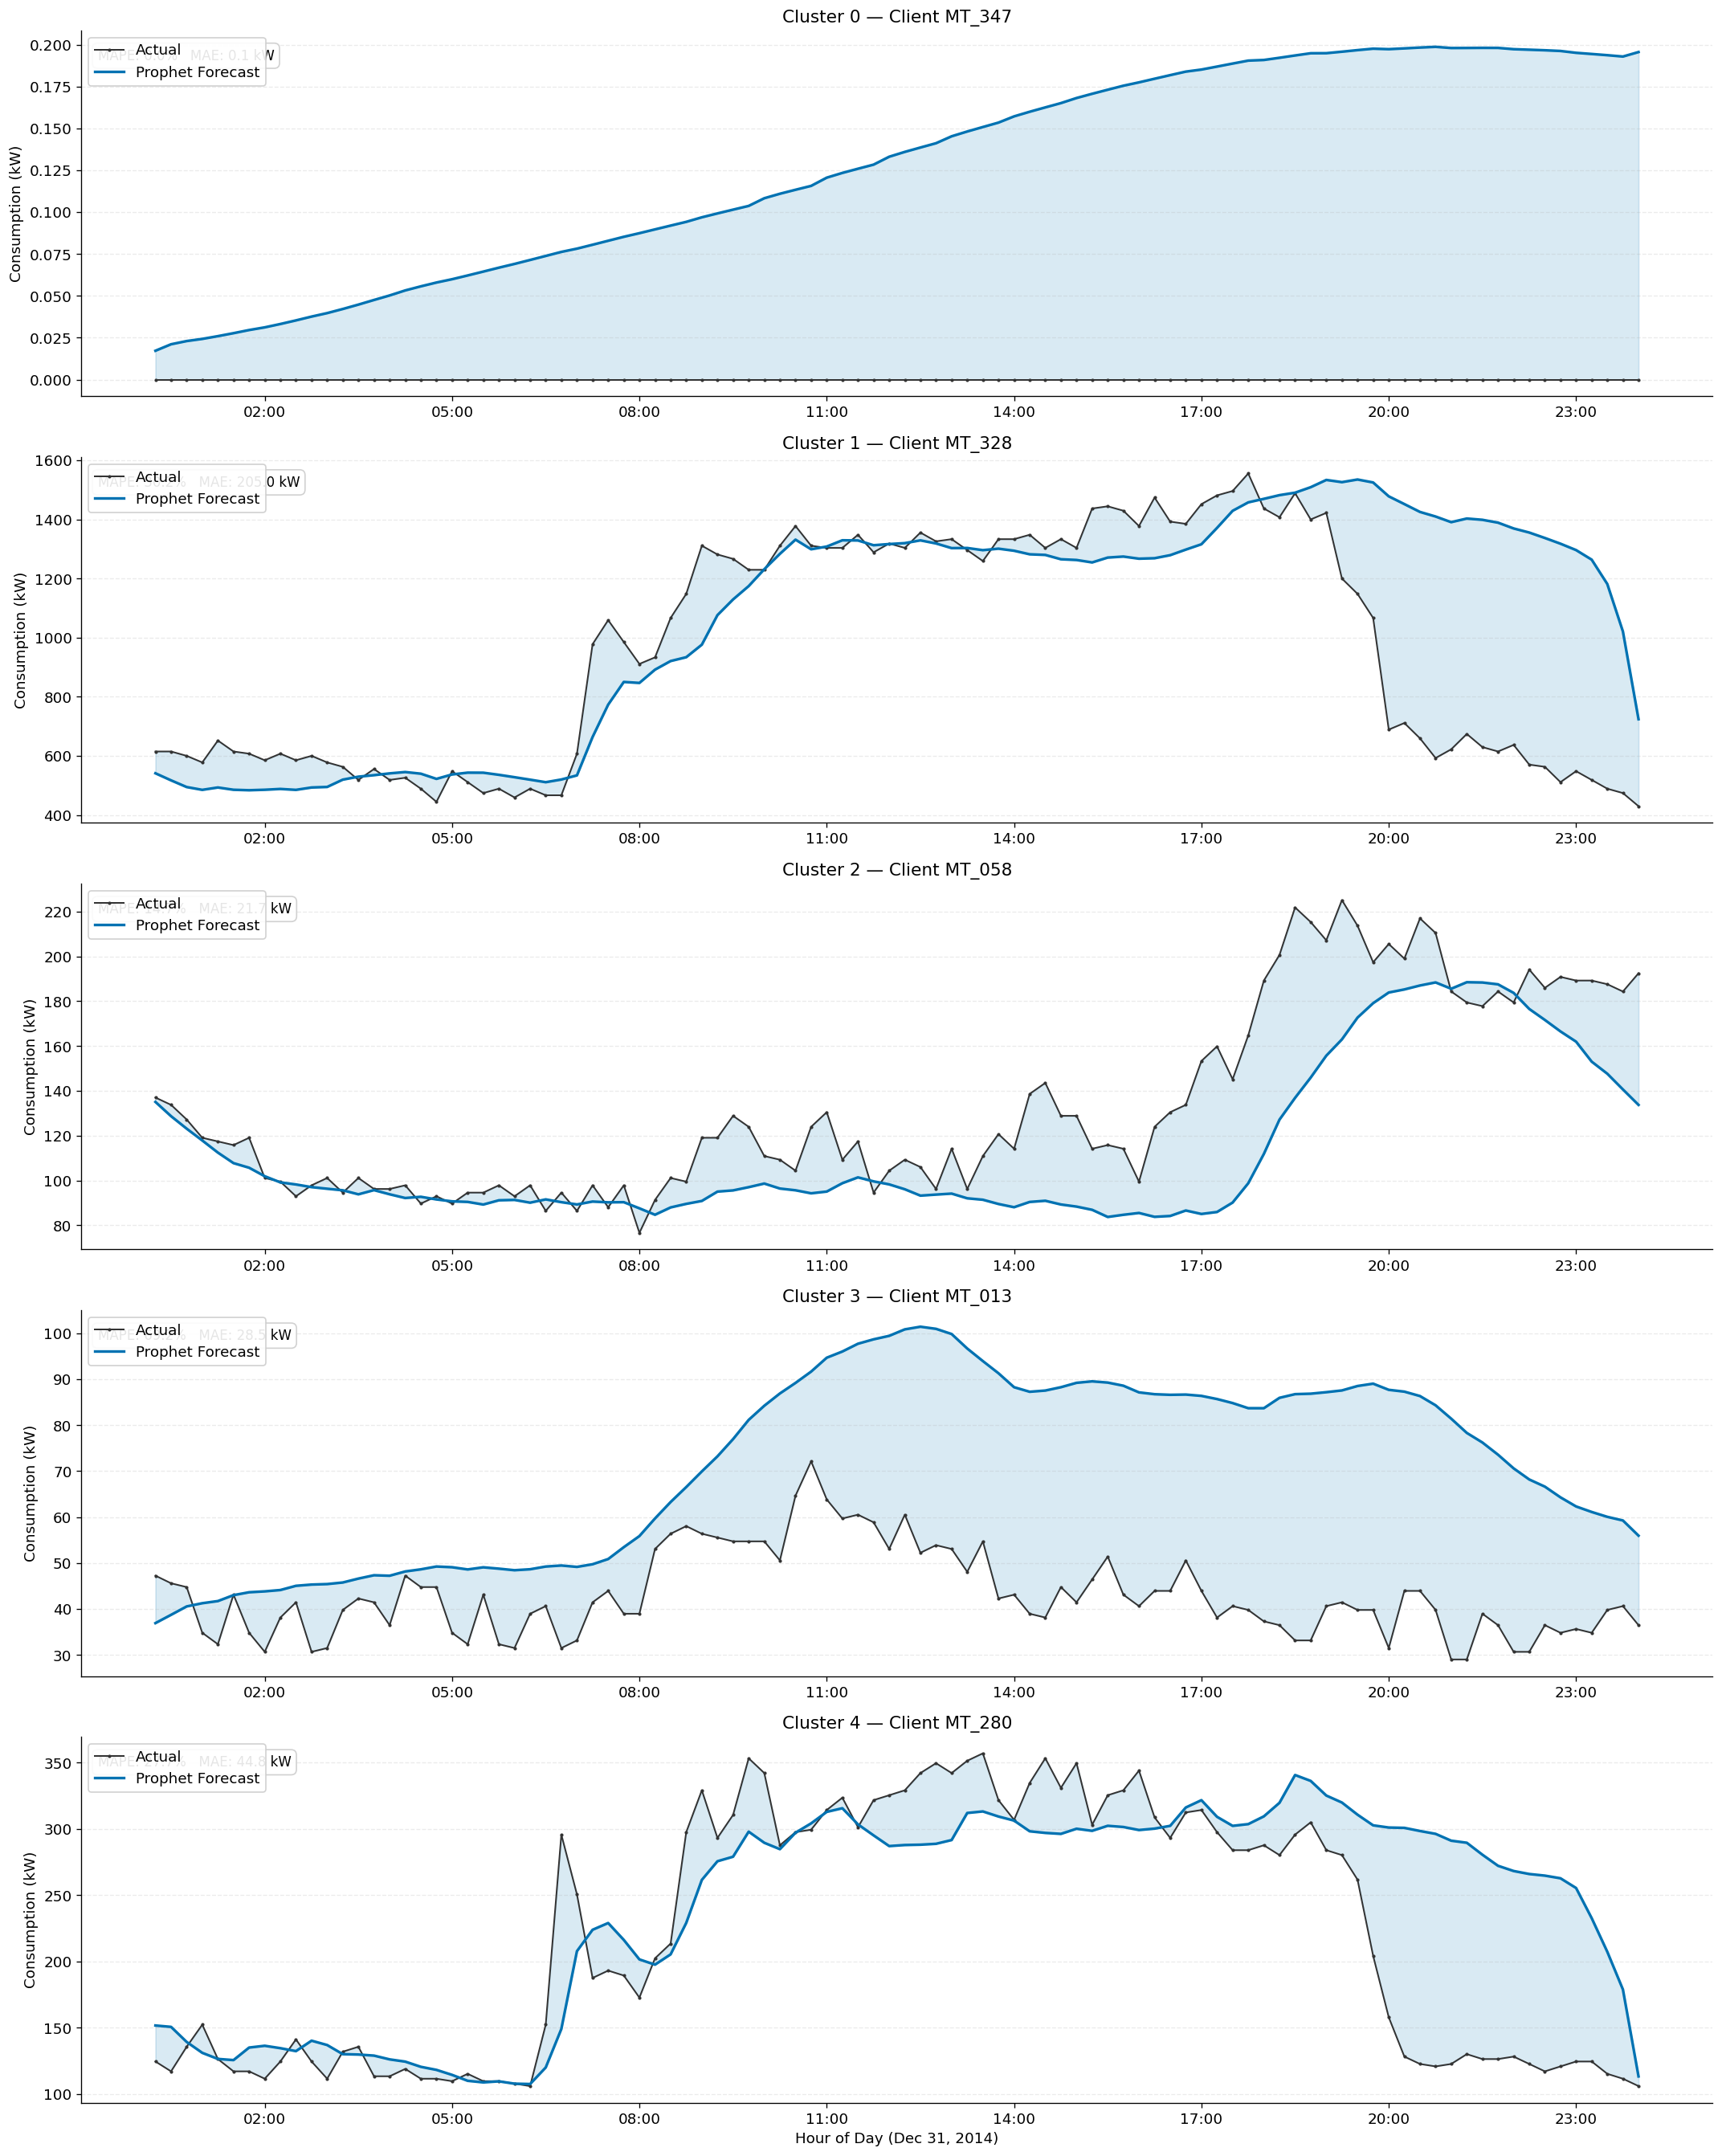

In [ ]:
# ---------------------------------------------------------
# 6. Visualization: One Client per Cluster
# ---------------------------------------------------------
cluster_representatives = (
    results_df.groupby('Cluster')['ClientID'].first().to_dict()
)

fig, axes = plt.subplots(len(cluster_representatives), 1,
                         figsize=(18, 4.5 * len(cluster_representatives)))
if len(cluster_representatives) == 1:
    axes = [axes]

for idx, (cluster_id, client_id) in enumerate(sorted(cluster_representatives.items())):
    ax = axes[idx]
    data = all_predictions[client_id]

    x      = data['test_df']['ds'].values
    y_true = data['test_df']['y'].values
    y_pred = data['y_pred']

    row      = results_df[results_df['ClientID'] == client_id].iloc[0]
    mae_val  = row['MAE']
    mape_val = row['MAPE']

    ax.plot(x, y_true, label='Actual', color='#333333', linewidth=1.2,
            marker='.', markersize=3)
    ax.plot(x, y_pred, label='Prophet Forecast', color='#0072B2', linewidth=2)
    ax.fill_between(x, y_true, y_pred, alpha=0.15, color='#0072B2')

    ax.text(0.01, 0.95, f"MAPE: {mape_val:.1%}   MAE: {mae_val:.1f} kW",
            transform=ax.transAxes, fontsize=10, va='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor='#cccccc', alpha=0.9))

    ax.set_title(f"Cluster {cluster_id} — Client {client_id}")
    ax.set_ylabel('Consumption (kW)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, alpha=0.25, linestyle='--')
    ax.xaxis.grid(False)
    ax.legend(loc='upper left', framealpha=0.9)

axes[-1].set_xlabel('Hour of Day (Dec 31, 2014)')
plt.tight_layout()
plt.show()